# 03 - Exploratory Analysis
**Goal:** validate and visualise the sales-side SQL results (`sql/02_sales_analysis.sql`) in Python, so every number in the project is cross-checked in two independent tools.

Question -> Analysis -> Visualization -> Finding -> Business implication, for each block below.

In [1]:
from pathlib import Path
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib.ticker as mticker, seaborn as sns
sns.set_theme(style="whitegrid", context="notebook"); pd.set_option("display.width", 160)
ROOT = Path("..").resolve(); PROC = ROOT / "data" / "processed"; SQL = ROOT / "reports" / "sql_results"
def brl(x, pos=None): return f"R${x/1000:,.0f}k" if abs(x) >= 1000 else f"R${x:,.0f}"

kpi = pd.read_csv(SQL / "02_sales_analysis__kpi_summary.csv").iloc[0]
print(f"Total orders (valid sales): {kpi.total_orders:,.0f}  |  Customers: {kpi.total_customers:,.0f}")
print(f"Revenue: R$ {kpi.total_revenue_brl:,.2f}  |  Freight: R$ {kpi.total_freight_brl:,.2f}  |  AOV: R$ {kpi.avg_order_value_brl:,.2f}")

Total orders (valid sales): 98,199  |  Customers: 94,983
Revenue: R$ 13,494,400.74  |  Freight: R$ 2,241,126.29  |  AOV: R$ 137.42


## Q1. How has monthly revenue and order volume trended?

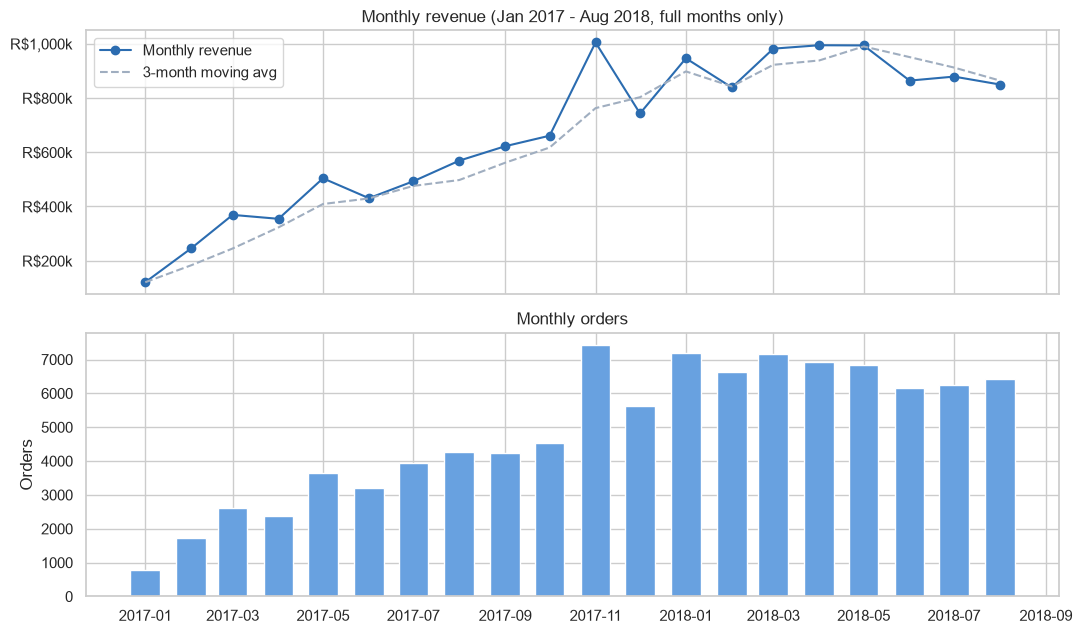

In [2]:
m = pd.read_csv(SQL / "02_sales_analysis__monthly_sales.csv", parse_dates=["month_start"])
fig, ax = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)
ax[0].plot(m.month_start, m.revenue_brl, marker="o", color="#2b6cb0", label="Monthly revenue")
ax[0].plot(m.month_start, m.revenue_3m_moving_avg_brl, ls="--", color="#a0aec0", label="3-month moving avg")
ax[0].yaxis.set_major_formatter(mticker.FuncFormatter(brl)); ax[0].set_title("Monthly revenue (Jan 2017 - Aug 2018, full months only)"); ax[0].legend()
ax[1].bar(m.month_start, m.orders, width=20, color="#68a1e0"); ax[1].set_title("Monthly orders"); ax[1].set_ylabel("Orders")
plt.tight_layout(); plt.savefig(ROOT/"reports"/"figures"/"monthly_revenue_orders.png", dpi=110); plt.show()

In [3]:
best, worst = m.loc[m.revenue_mom_pct.idxmax()], m.loc[m.revenue_mom_pct.idxmin()]
print(f"Strongest MoM growth: {best.month_start.strftime('%b %Y')} ({best.revenue_mom_pct:+.1f}%)")
print(f"Sharpest MoM drop: {worst.month_start.strftime('%b %Y')} ({worst.revenue_mom_pct:+.1f}%)")

Strongest MoM growth: Feb 2017 (+104.0%)
Sharpest MoM drop: Dec 2017 (-26.1%)


**Finding:** revenue climbs steadily from R$120k (Jan 2017) to a plateau of roughly R$850k-1.0M/month from late 2017 onward, growing almost 7x over the period, then flattening in 2018 with a seasonal spike in Nov 2017 (Black Friday). **Implication:** the business scaled fast in its first year and has since matured to a stable run-rate; growth initiatives should target the plateau rather than assume organic momentum continues.

## Q2. Which regions and states generate the most revenue?

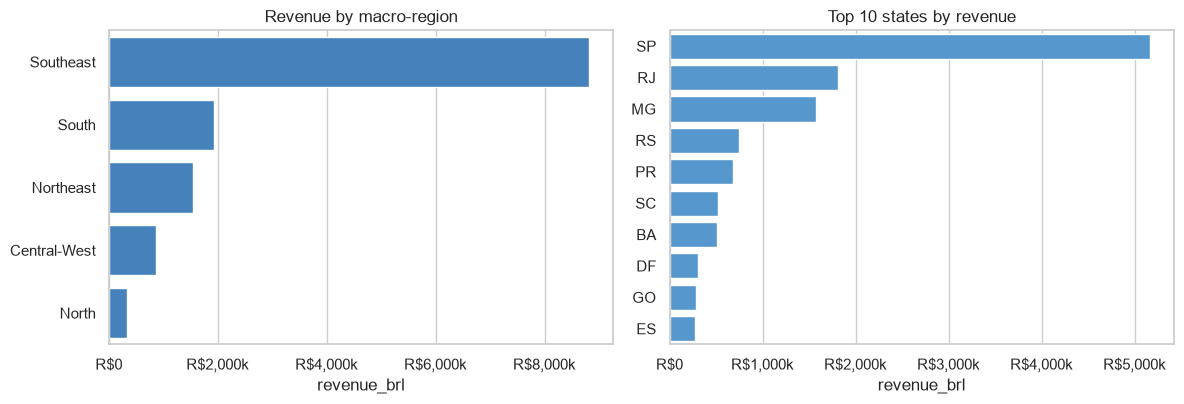

Southeast alone = 65.4% of revenue; SP alone = 38.3%


In [4]:
reg = pd.read_csv(SQL / "02_sales_analysis__revenue_by_region.csv")
st = pd.read_csv(SQL / "02_sales_analysis__revenue_by_state.csv")
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
sns.barplot(data=reg, y="region", x="revenue_brl", ax=ax[0], color="#3182ce"); ax[0].xaxis.set_major_formatter(mticker.FuncFormatter(brl)); ax[0].set_title("Revenue by macro-region"); ax[0].set_ylabel("")
sns.barplot(data=st.head(10), y="state", x="revenue_brl", ax=ax[1], color="#4299e1"); ax[1].xaxis.set_major_formatter(mticker.FuncFormatter(brl)); ax[1].set_title("Top 10 states by revenue"); ax[1].set_ylabel("")
plt.tight_layout(); plt.savefig(ROOT/"reports"/"figures"/"revenue_by_geography.png", dpi=110); plt.show()
print(f"Southeast alone = {reg.iloc[0].revenue_share_pct:.1f}% of revenue; SP alone = {st.iloc[0].revenue_share_pct:.1f}%")

**Finding:** the Southeast region (SP, RJ, MG, ES) drives roughly two-thirds of revenue, and São Paulo state alone is the single biggest contributor. Northern/Northeastern states have higher freight-to-price ratios, consistent with longer shipping distances. **Implication:** logistics investment in the Southeast protects the core; freight subsidy or regional fulfillment could unlock the North/Northeast, where freight burden discourages purchases.

## Q3. How is revenue split across order status and payment type?

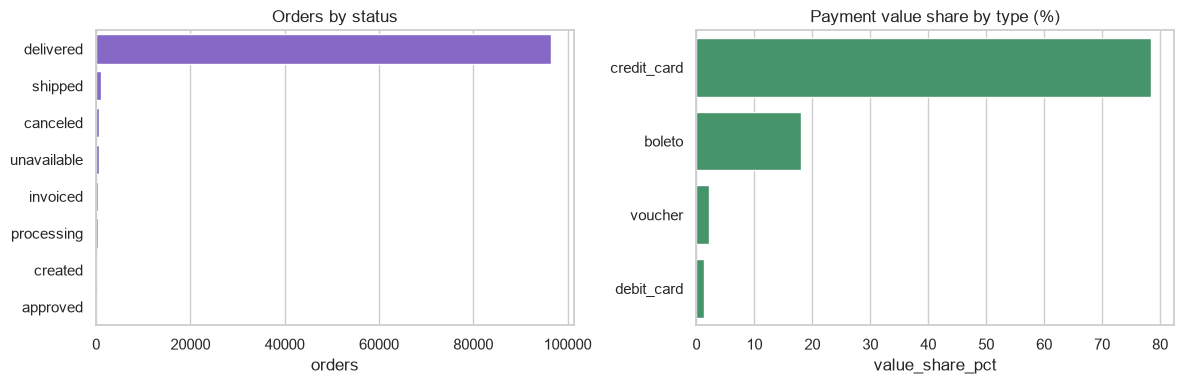

In [5]:
st_ = pd.read_csv(SQL / "02_sales_analysis__orders_by_status.csv")
pay = pd.read_csv(SQL / "02_sales_analysis__payment_type_mix.csv")
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=st_, y="order_status", x="orders", ax=ax[0], color="#805ad5"); ax[0].set_title("Orders by status"); ax[0].set_ylabel("")
sns.barplot(data=pay, y="payment_type", x="value_share_pct", ax=ax[1], color="#38a169"); ax[1].set_title("Payment value share by type (%)"); ax[1].set_ylabel("")
plt.tight_layout(); plt.savefig(ROOT/"reports"/"figures"/"status_and_payment.png", dpi=110); plt.show()

**Finding:** 97% of orders reach `delivered`; canceled + unavailable together are only 1.25% of orders and are excluded from revenue. Credit card dominates payment value (~78%), with an average of several installments, indicating price-sensitive Brazilian consumers financing purchases.

## Q4. Item price and freight distribution (why we use medians, not just averages)

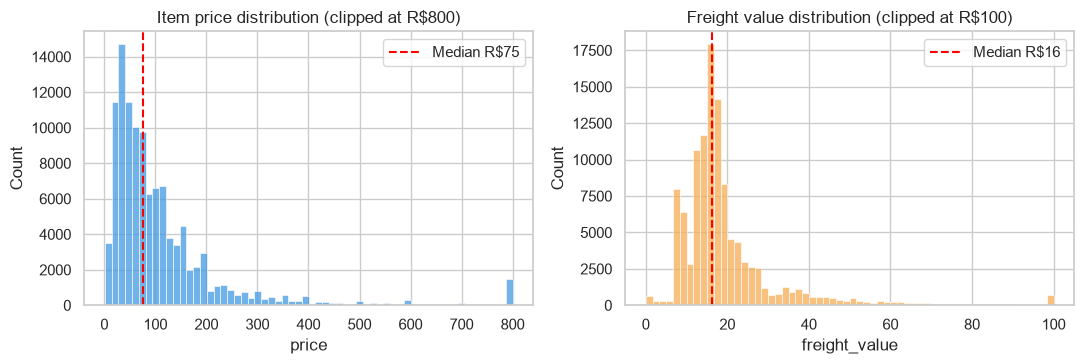

Mean price R$120.65 vs median R$74.99 -- mean is pulled up by a long tail of expensive items


In [6]:
items = pd.read_csv(PROC / "order_items_clean.csv")
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
sns.histplot(items.price.clip(upper=800), bins=60, ax=ax[0], color="#4299e1"); ax[0].axvline(items.price.median(), color="red", ls="--", label=f"Median R${items.price.median():.0f}")
ax[0].set_title("Item price distribution (clipped at R$800)"); ax[0].legend()
sns.histplot(items.freight_value.clip(upper=100), bins=60, ax=ax[1], color="#f6ad55"); ax[1].axvline(items.freight_value.median(), color="red", ls="--", label=f"Median R${items.freight_value.median():.0f}")
ax[1].set_title("Freight value distribution (clipped at R$100)"); ax[1].legend()
plt.tight_layout(); plt.savefig(ROOT/"reports"/"figures"/"price_freight_distribution.png", dpi=110); plt.show()
print(f"Mean price R${items.price.mean():.2f} vs median R${items.price.median():.2f} -- mean is pulled up by a long tail of expensive items")

**Finding:** both distributions are right-skewed with long tails of expensive/bulky items (confirmed earlier in notebook 02). **Implication:** report medians alongside means for pricing/freight KPIs on the dashboard, or averages will overstate the 'typical' order.